# XGBoost Forecast for air_no2
This notebook builds an XGBoost model to forecast air_no2

## 1 — Import Required Libraries

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBRegressor
from matplotlib.patches import Patch
import joblib

print('All libraries loaded successfully.')


All libraries loaded successfully.


## 2 — Configuration

In [2]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
CANDIDATE_PATHS = [
    NOTEBOOK_DIR / 'combined_air_electricity_ipi_cleaned.csv',
    NOTEBOOK_DIR.parent / 'COS40007DataCleaning' / 'combined_air_electricity_ipi_cleaned.csv',
    NOTEBOOK_DIR.parent / 'public' / 'data' / 'combined_air_electricity_ipi_cleaned.csv',
]
FILE_PATH = next((p for p in CANDIDATE_PATHS if p.exists()), None)
if FILE_PATH is None:
    raise FileNotFoundError('Could not find combined_air_electricity_ipi_cleaned.csv')

TARGET_COL  = 'air_no2'    
TEST_SIZE   = 12                
LOOKBACK    = 3                
SEED        = 42

BEST_PARAMS = {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.005, 'reg_lambda': 0.01, 'min_child_weight': 3, 'subsample': 0.9, 'colsample_bytree': 0.8, 'objective': 'reg:squarederror', 'random_state': 42, 'verbosity': 0}

## 3 — Load CSV Dataset

In [3]:
df = pd.read_csv(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Forecast target: {TARGET_COL}')
print(f'Dataset shape before outlier removal: {df.shape}')
print('First 5 rows:')
print(df[['date', TARGET_COL]].head())
print('Last 5 rows:')
print(df[['date', TARGET_COL]].tail())


Forecast target: air_no2
Dataset shape before outlier removal: (60, 20)
First 5 rows:
        date  air_no2
0 2018-01-01   0.0078
1 2018-02-01   0.0069
2 2018-03-01   0.0074
3 2018-04-01   0.0075
4 2018-05-01   0.0076
Last 5 rows:
         date  air_no2
55 2022-08-01   0.0067
56 2022-09-01   0.0067
57 2022-10-01   0.0063
58 2022-11-01   0.0066
59 2022-12-01   0.0062


## 4 — Outlier Smoothing (Z-Score, threshold = 3)
values with |Z-score| > 3 are replaced with NaN and linearly interpolated.


In [4]:
z_scores = np.abs(zscore(df[TARGET_COL]))
df[TARGET_COL] = np.where(z_scores > 3, np.nan, df[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].interpolate()

print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Total months after outlier smoothing: {len(df)}')
print(f'Outliers smoothed: {(z_scores > 3).sum()}')


Date range: 2018-01-01 00:00:00 to 2022-12-01 00:00:00
Total months after outlier smoothing: 60
Outliers smoothed: 1


## 5 — Log Transformation & ADF Stationarity Test


In [5]:
df.set_index('date', inplace=True)
df[f'log_{TARGET_COL}'] = np.log(df[TARGET_COL])
log_series = df[f'log_{TARGET_COL}']
print(f'Log transformation applied to {TARGET_COL}.')

def run_adf_test(series, alpha=0.05):
    result = adfuller(series, autolag='AIC')
    print(f"ADF statistic: {result[0]:.4f}, p-value: {result[1]:.4f}, usedlag: {result[2]}, nobs: {result[3]}")
    return result[1] <= alpha

difference_order = 0
processed_series = log_series.copy()
print("\nADF test on log-transformed series:")
if not run_adf_test(processed_series):
    processed_series = processed_series.diff().dropna()
    difference_order = 1
    print("Series was not stationary. Applied first-order differencing.")
    print("\nADF test after first differencing:")
    if not run_adf_test(processed_series):
        processed_series = processed_series.diff().dropna()
        difference_order = 2
        print("Series still not stationary. Applied second-order differencing.")
        print("\nADF test after second differencing:")
        if not run_adf_test(processed_series):
            print("Warning: series is still non-stationary after second differencing.")

if difference_order == 0:
    print("\nFinal series uses log-transformed values with no differencing.")
else:
    print(f"\nFinal series uses log-transformed values with differencing order = {difference_order}.")

print(f"Final processed data length: {len(processed_series)}")
data = processed_series.values.reshape(-1, 1)
print(f"Data shape: {data.shape}")


Log transformation applied to air_no2.

ADF test on log-transformed series:
ADF statistic: -2.6690, p-value: 0.0796, usedlag: 1, nobs: 58
Series was not stationary. Applied first-order differencing.

ADF test after first differencing:
ADF statistic: -5.9926, p-value: 0.0000, usedlag: 2, nobs: 56

Final series uses log-transformed values with differencing order = 1.
Final processed data length: 59
Data shape: (59, 1)


## 6 — Split Data into Train and Test (Last 12 Months)

In [6]:
train_data = data[:-TEST_SIZE]
test_data  = data[-TEST_SIZE:]

print(f'Train data shape: {train_data.shape}')
print(f'Test  data shape: {test_data.shape}')
print(f'Train range: {len(train_data)} months')
print(f'Test  range: {len(test_data)} months')


Train data shape: (47, 1)
Test  data shape: (12, 1)
Train range: 47 months
Test  range: 12 months


## 7 — Scale Data with MinMaxScaler After Split


In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print(f'Scaled train shape: {train_scaled.shape}')
print(f'Scaled test  shape: {test_scaled.shape}')
print(f'Scaler min: {scaler.data_min_[0]:.4f}, max: {scaler.data_max_[0]:.4f}')


Scaled train shape: (47, 1)
Scaled test  shape: (12, 1)
Scaler min: -0.2489, max: 0.2607


## 8 — Build Lag Features (Lookback = 3)

| Feature | Description |
|---|---|
| lag1 – lag3 | Past 3 scaled values (autoregressive) |
| roll_mean3 | 3-step rolling mean (local trend) |
| roll_std3 | 3-step rolling std (volatility) |
| month | Calendar month (seasonality) |


In [8]:
def create_features(scaled_data, dates_index, lookback):
    rows = []
    for i in range(lookback, len(scaled_data)):
        r = {}
        for lag in range(1, lookback + 1):
            r[f'lag{lag}'] = scaled_data[i - lag, 0]
        r['roll_mean3'] = np.mean(scaled_data[max(0, i-3):i, 0])
        r['roll_std3']  = np.std(scaled_data[max(0, i-3):i, 0])
        r['month']      = dates_index[i].month
        rows.append(r)
    feat_df = pd.DataFrame(rows, index=dates_index[lookback:])
    target  = scaled_data[lookback:, 0]
    return feat_df, target

test_extended = np.vstack((train_scaled[-LOOKBACK:], test_scaled))

X_train_feat, y_train_feat = create_features(
    train_scaled, processed_series.index[:len(train_data)], LOOKBACK
)

test_ext_dates = processed_series.index[len(train_data) - LOOKBACK:]
X_test_feat, y_test_feat = create_features(test_extended, test_ext_dates, LOOKBACK)

FEATURE_COLS = X_train_feat.columns.tolist()

print(f'X_train shape: {X_train_feat.shape}')
print(f'X_test  shape: {X_test_feat.shape}')
print(f'Features: {FEATURE_COLS}')


X_train shape: (44, 6)
X_test  shape: (12, 6)
Features: ['lag1', 'lag2', 'lag3', 'roll_mean3', 'roll_std3', 'month']


## 9 — Walk-Forward Validation
initial_train_size=20, val_size=4, n_splits=3.
Each fold trains XGBoost from scratch on the accumulated window and validates
on the next 4 steps — no leakage between folds.


In [9]:
def walk_forward_validation_xgb(train_scaled, dates_index, lookback=3,
                                  val_size=4, n_splits=3, initial_train_size=20):
    total_len = len(train_scaled)
    max_splits = (total_len - lookback - val_size) // val_size
    if max_splits < 1:
        raise ValueError('Not enough data for walk-forward validation.')
    n_splits = min(n_splits, max_splits)
    metrics = []

    for split in range(n_splits):
        train_end = initial_train_size + (split + 1) * val_size
        val_start = train_end
        val_end   = val_start + val_size
        if val_end > total_len:
            print(f'Fold {split + 1}: not enough data, skipping.')
            break

        train_window = train_scaled[:train_end]
        val_window   = train_scaled[val_start:val_end]
        window_dates = dates_index[:val_end]

        Xtr_w, ytr_w = create_features(train_window, window_dates[:train_end], lookback)

        # Val portion features (extend with last lookback of train)
        val_ext       = np.vstack((train_window[-lookback:], val_window))
        val_ext_dates = dates_index[train_end - lookback:val_end]
        Xva_w, yva_w  = create_features(val_ext, val_ext_dates, lookback)

        fold_model = XGBRegressor(**BEST_PARAMS)
        fold_model.fit(Xtr_w, ytr_w)

        yva_pred = fold_model.predict(Xva_w)
        mse  = mean_squared_error(yva_w, yva_pred)
        rmse = np.sqrt(mse)
        r2   = r2_score(yva_w, yva_pred)
        metrics.append((mse, rmse, r2))
        print(f'Fold {split+1}: train_end={train_end}, val_end={val_end}, '
              f'MSE={mse:.6f}, RMSE={rmse:.6f}, R²={r2:.6f}')

    return metrics

metrics = walk_forward_validation_xgb(
    train_scaled,
    processed_series.index[:len(train_data)],
    lookback=LOOKBACK, val_size=4, n_splits=3, initial_train_size=20
)

mse_vals  = [m[0] for m in metrics]
rmse_vals = [m[1] for m in metrics]
r2_vals   = [m[2] for m in metrics]

print('Walk-forward validation summary:')
print(f'Average MSE:  {np.mean(mse_vals):.6f}')
print(f'Average RMSE: {np.mean(rmse_vals):.6f}')
print(f'Average R²:   {np.mean(r2_vals):.6f}')


Fold 1: train_end=24, val_end=28, MSE=0.013464, RMSE=0.116034, R²=-2.522345
Fold 2: train_end=28, val_end=32, MSE=0.085901, RMSE=0.293089, R²=-0.842905
Fold 3: train_end=32, val_end=36, MSE=0.039998, RMSE=0.199995, R²=-0.083635
Walk-forward validation summary:
Average MSE:  0.046454
Average RMSE: 0.203039
Average R²:   -1.149628


## 10 — Train Final XGBoost Model on Full Training Set

In [10]:
print('Training final XGBoost model on the full training set...')

model = XGBRegressor(**BEST_PARAMS)
model.fit(X_train_feat, y_train_feat,
          eval_set=[(X_train_feat, y_train_feat), (X_test_feat, y_test_feat)],
          verbose=False)

print('Training completed!')


Training final XGBoost model on the full training set...
Training completed!


## 11 — Evaluate with MSE, RMSE, and R² (Scaled Data)


In [11]:
y_pred_scaled = model.predict(X_test_feat)

mse_scaled  = mean_squared_error(y_test_feat, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled   = r2_score(y_test_feat, y_pred_scaled)

print('=== Metrics on Scaled Data ===')
print(f'MSE (scaled):  {mse_scaled:.6f}')
print(f'RMSE (scaled): {rmse_scaled:.6f}')
print(f'R² (scaled):   {r2_scaled:.6f}')


=== Metrics on Scaled Data ===
MSE (scaled):  0.024093
RMSE (scaled): 0.155220
R² (scaled):   0.014440


## 12 — Inverse Scale Predictions


In [12]:

y_pred_diff_vals = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_test_diff_vals = scaler.inverse_transform(y_test_feat.reshape(-1, 1))

if difference_order == 0:
    y_pred_log_values = y_pred_diff_vals
    y_test_log_values = y_test_diff_vals

elif difference_order == 1:
    prev1 = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff_vals + prev1
    y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)

else:  # difference_order == 2
    prev1 = log_series.iloc[-TEST_SIZE - 1:-1].values.reshape(-1, 1)
    prev2 = log_series.iloc[-TEST_SIZE - 2:-2].values.reshape(-1, 1)
    y_pred_log_values = y_pred_diff_vals + 2 * prev1 - prev2
    y_test_log_values = log_series.iloc[-TEST_SIZE:].values.reshape(-1, 1)

y_pred_original = np.exp(y_pred_log_values)
y_test_original = np.exp(y_test_log_values)

assert y_pred_original.shape == y_test_original.shape, \
    f'Shape mismatch! Preds: {y_pred_original.shape}, Actuals: {y_test_original.shape}'
assert len(y_pred_original) == TEST_SIZE, \
    f'Expected {TEST_SIZE} predictions, got {len(y_pred_original)}'

mse_original  = mean_squared_error(y_test_original, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original   = r2_score(y_test_original, y_pred_original)

print('=== Metrics on Original Scale ===')
print(f'MSE  (original): {mse_original:.20f}')
print(f'RMSE (original): {rmse_original:.20f}')
print(f'R²   (original): {r2_original:.6f}')


=== Metrics on Original Scale ===
MSE  (original): 0.00000022427499234106
RMSE (original): 0.00047357680722461665
R²   (original): -0.192600


## 13   Plot Prediction vs Actual
Car-forecast display layout: full history/test forecast, test detail, scatter, learning curves, feature importance. Figure is displayed inline only (not saved as PNG).


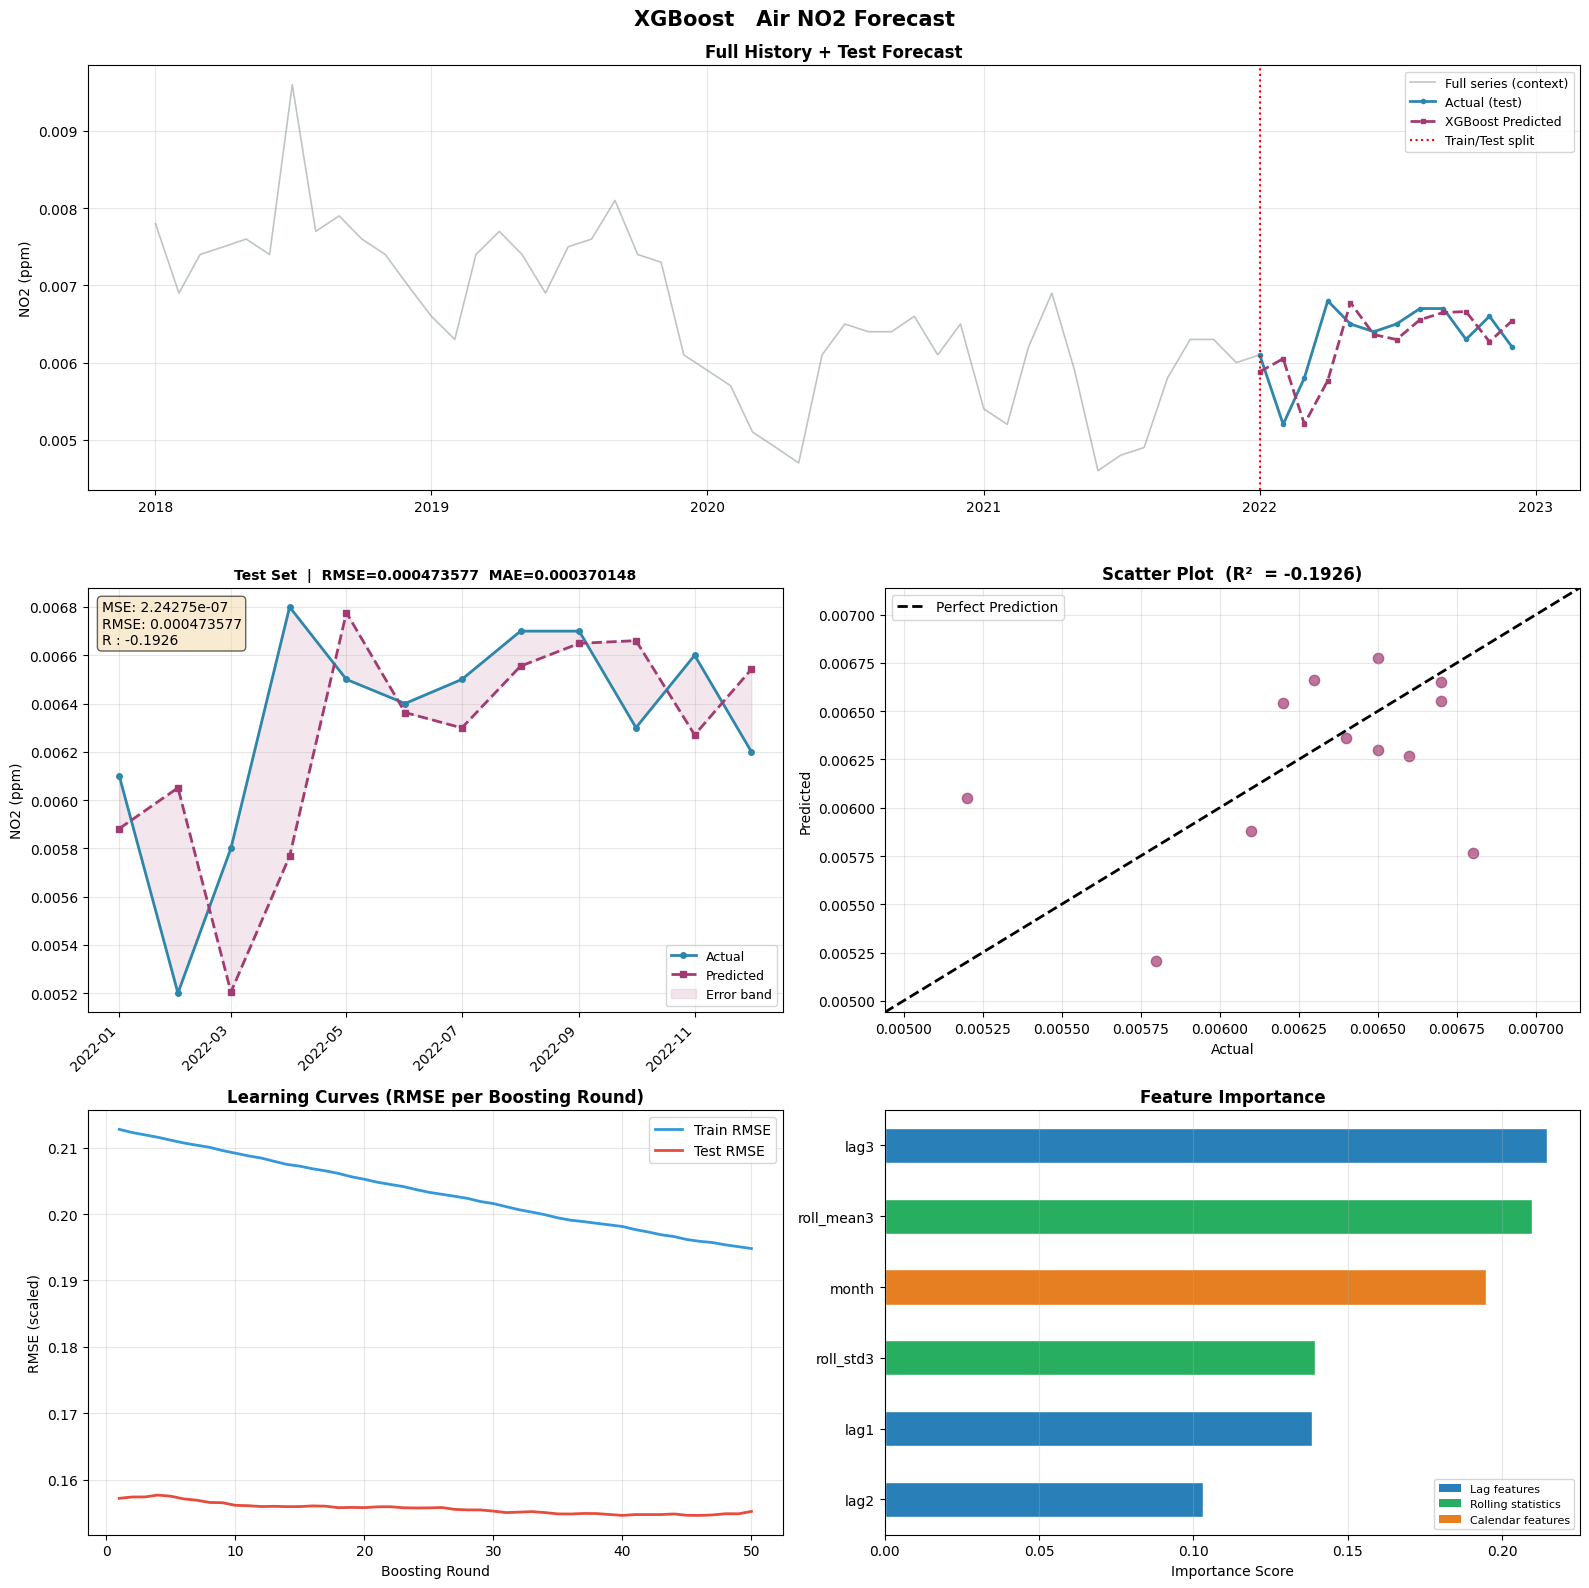


  XGBoost forecast completed.
Figure is displayed inline in the notebook only (no PNG file saved to disk).


In [13]:
test_dates  = processed_series.index[-TEST_SIZE:]
train_dates = X_train_feat.index
evals       = model.evals_result()
tr_curve    = evals['validation_0']['rmse']
te_curve    = evals['validation_1']['rmse']
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
imp_colors  = ['#2980b9' if 'lag' in f else
               '#27ae60' if 'roll' in f else '#e67e22'
               for f in importances.index]

mae_original = mean_absolute_error(y_test_original, y_pred_original)
y_axis_labels = {
    'air_no2': 'NO2 (ppm)',
    'electricity_local': 'Electricity (GWh)',
    'ipi_abs_index_sa': 'IPI Abs Index SA',
}
title_labels = {
    'air_no2': 'Air NO2',
    'electricity_local': 'Electricity Local',
    'ipi_abs_index_sa': 'IPI Absolute Index SA',
}
y_axis_label = y_axis_labels.get(TARGET_COL, TARGET_COL)
title_label = title_labels.get(TARGET_COL, TARGET_COL)

fig = plt.figure(figsize=(16, 16))
fig.suptitle(f'XGBoost   {title_label} Forecast',
             fontsize=15, fontweight='bold', y=0.99)

ax0 = fig.add_subplot(3, 2, (1, 2))
ax0.plot(df.index, df[TARGET_COL], color='#7f8c8d', lw=1.2,
         alpha=0.5, label='Full series (context)')
ax0.plot(test_dates, y_test_original.flatten(),
         color='#2E86AB', lw=2, marker='o', ms=3, label='Actual (test)')
ax0.plot(test_dates, y_pred_original.flatten(),
         color='#A23B72', lw=2, ls='--', marker='s', ms=3, label='XGBoost Predicted')
ax0.axvline(test_dates[0], color='red', ls=':', lw=1.5, label='Train/Test split')
ax0.set_title('Full History + Test Forecast', fontweight='bold')
ax0.set_ylabel(y_axis_label)
ax0.legend(fontsize=9); ax0.grid(alpha=0.3)
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax1 = fig.add_subplot(3, 2, 3)
ax1.plot(test_dates, y_test_original.flatten(),
         color='#2E86AB', lw=2, marker='o', ms=4, label='Actual')
ax1.plot(test_dates, y_pred_original.flatten(),
         color='#A23B72', lw=2, ls='--', marker='s', ms=4, label='Predicted')
ax1.fill_between(test_dates, y_test_original.flatten(), y_pred_original.flatten(),
                 alpha=0.12, color='#A23B72', label='Error band')
ax1.set_title(f'Test Set  |  RMSE={rmse_original:.6g}  MAE={mae_original:.6g}',
              fontweight='bold', fontsize=10)
ax1.set_ylabel(y_axis_label)
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.text(0.02, 0.97,
         f'MSE: {mse_original:.6g}\nRMSE: {rmse_original:.6g}\nR : {r2_original:.4f}',
         transform=ax1.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

ax2 = fig.add_subplot(3, 2, 4)
ax2.scatter(y_test_original.flatten(), y_pred_original.flatten(),
            alpha=0.7, s=55, color='#A23B72')
lim = [min(y_test_original.min(), y_pred_original.min()) * 0.95,
       max(y_test_original.max(), y_pred_original.max()) * 1.05]
ax2.plot(lim, lim, 'k--', lw=2, label='Perfect Prediction')
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_title(f'Scatter Plot  (R²  = {r2_original:.4f})', fontweight='bold')
ax2.set_xlabel('Actual'); ax2.set_ylabel('Predicted')
ax2.legend(); ax2.grid(alpha=0.3)

#   Learning curves
ax3 = fig.add_subplot(3, 2, 5)
ax3.plot(range(1, len(tr_curve)+1), tr_curve, color='#3498db', lw=2, label='Train RMSE')
ax3.plot(range(1, len(te_curve)+1), te_curve, color='#e74c3c', lw=2, label='Test RMSE')
ax3.set_title('Learning Curves (RMSE per Boosting Round)', fontweight='bold')
ax3.set_xlabel('Boosting Round'); ax3.set_ylabel('RMSE (scaled)')
ax3.legend(); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(3, 2, 6)
importances.plot(kind='barh', ax=ax4, color=imp_colors, edgecolor='white')
ax4.set_title('Feature Importance', fontweight='bold')
ax4.set_xlabel('Importance Score')
ax4.legend(handles=[
    Patch(facecolor='#2980b9', label='Lag features'),
    Patch(facecolor='#27ae60', label='Rolling statistics'),
    Patch(facecolor='#e67e22', label='Calendar features'),
], loc='lower right', fontsize=8)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

png_path = Path.cwd() / f'xgboost_{TARGET_COL}_predictions.png'
if png_path.exists():
    png_path.unlink()

print('\n  XGBoost forecast completed.')
print('Figure is displayed inline in the notebook only (no PNG file saved to disk).')


## 14 Results Summary


In [14]:
print('=' * 57)
print(f'   XGBOOST {title_label.upper()} FINAL RESULTS')
print('=' * 57)
print(f'  MSE  (original) : {mse_original:>15.6g}')
print(f'  RMSE (original) : {rmse_original:>15.6g}')
print(f'  MAE  (original) : {mae_original:>15.6g}')
print(f'  R²   (original) : {r2_original:>15.6f}')
print('-' * 57)
print(f'  MSE  (scaled)   : {mse_scaled:>15.6f}')
print(f'  RMSE (scaled)   : {rmse_scaled:>15.6f}')
print(f'  R²   (scaled)   : {r2_scaled:>15.6f}')
print('=' * 57)
print(f'  Lookback        : {LOOKBACK} months')
print(f'  Test period     : {processed_series.index[-TEST_SIZE]:%b %Y} - {processed_series.index[-1]:%b %Y}')
print(f'  difference_order: {difference_order}')
print('\n  Hyperparameters:')
for k, v in BEST_PARAMS.items():
    if k not in ('objective', 'verbosity', 'random_state'):
        print(f'    {k:<22}: {v}')
print('\n  Top 5 features by importance:')
for f, s in importances.tail(5).iloc[::-1].items():
    print(f'    {f:<15}: {s:.4f}')
print('=' * 57)
print(f'\n  Walk-forward CV avg R²: {np.mean([m[2] for m in metrics]):.4f}')


   XGBOOST AIR NO2 FINAL RESULTS
  MSE  (original) :     2.24275e-07
  RMSE (original) :     0.000473577
  MAE  (original) :     0.000370148
  R²   (original) :       -0.192600
---------------------------------------------------------
  MSE  (scaled)   :        0.024093
  RMSE (scaled)   :        0.155220
  R²   (scaled)   :        0.014440
  Lookback        : 3 months
  Test period     : Jan 2022 - Dec 2022
  difference_order: 1

  Hyperparameters:
    n_estimators          : 50
    max_depth             : 3
    learning_rate         : 0.005
    reg_lambda            : 0.01
    min_child_weight      : 3
    subsample             : 0.9
    colsample_bytree      : 0.8

  Top 5 features by importance:
    lag3           : 0.2145
    roll_mean3     : 0.2097
    month          : 0.1948
    roll_std3      : 0.1394
    lag1           : 0.1385

  Walk-forward CV avg R²: -1.1496


## 15 — Save Model
Saves in two formats matching project conventions:
- xgboost_model_forecast_air_no2.json — XGBoost native format (reload with model.load_model())
- xgboost_model_forecast_air_no2.pkl — joblib bundle with model + scaler + metadata


In [15]:
# XGBoost native format
model.save_model('xgboost_model_air_no2_forecast.json')

# Joblib bundle (.pkl)
bundle = {
    'model'           : model,
    'scaler'          : scaler,
    'feature_cols'    : FEATURE_COLS,
    'lookback'        : LOOKBACK,
    'test_size'       : TEST_SIZE,
    'difference_order': difference_order,
    'best_params'     : BEST_PARAMS,
    'mse_scaled'      : float(mse_scaled),
    'rmse_scaled'     : float(rmse_scaled),
    'r2_scaled'       : float(r2_scaled),
    'mse_original'    : float(mse_original),
    'rmse_original'   : float(rmse_original),
    'r2_original'     : float(r2_original),
}
joblib.dump(bundle, 'xgboost_model_air_no2_forecast.pkl')

print('Model saved (XGBoost native) : xgboost_model_air_no2_forecast.json')
print('Model saved (joblib bundle)  : xgboost_model_air_no2_forecast.pkl')
print(f'Bundle keys: {list(bundle.keys())}')
print()
print('To reload:')
print('  bundle = joblib.load("xgboost_model_air_no2_forecast.pkl")')
print('  model  = bundle["model"]')
print('  scaler = bundle["scaler"]')


Model saved (XGBoost native) : xgboost_model_air_no2_forecast.json
Model saved (joblib bundle)  : xgboost_model_air_no2_forecast.pkl
Bundle keys: ['model', 'scaler', 'feature_cols', 'lookback', 'test_size', 'difference_order', 'best_params', 'mse_scaled', 'rmse_scaled', 'r2_scaled', 'mse_original', 'rmse_original', 'r2_original']

To reload:
  bundle = joblib.load("xgboost_model_air_no2_forecast.pkl")
  model  = bundle["model"]
  scaler = bundle["scaler"]
